<b><font color="#1f4e79" size="7">
Notebook 1:
<br></font></b>

<b><font color="#1f4e79" size="6">
Downloading rs-fMRI Data and ROI Time-Series Extraction
</font></b>

<hr>



This notebook implements a complete pipeline for:

- Downloading preprocessed resting-state fMRI data from OpenNeuro (ds002748)
- Validating data integrity across subjects
- Extracting ROI-level time series using the AAL3 atlas
- Applying confound regression, temporal filtering, and standardization
- Saving extracted signals for downstream analysis


# Setup

## Install & Imports

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

!pip install nilearn --quiet
!pip install awscli --quiet
from nilearn import plotting, datasets, image
from nilearn.maskers import NiftiLabelsMasker


## Downloading the ds002748 Dataset

In this section, we download the **preprocessed resting-state BOLD fMRI** and corresponding **confound files** for all 72 participants in the ds002748 dataset.

The dataset includes:
- 21 healthy controls (HC)
- 51 patients with major depressive disorder (MDD)

The download takes about 5 minutes on Google Colab.

In [ ]:
!aws s3 sync s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/ /content/ds002748/ \
    --no-sign-request \
    --exclude "*" \
    --include "*_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz" \
    --include "*_desc-confounds_timeseries.tsv"

download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-01/func/sub-01_task-rest_desc-confounds_timeseries.tsv to ds002748/sub-01/func/sub-01_task-rest_desc-confounds_timeseries.tsv
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-02/func/sub-02_task-rest_desc-confounds_timeseries.tsv to ds002748/sub-02/func/sub-02_task-rest_desc-confounds_timeseries.tsv
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-02/func/sub-02_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz to ds002748/sub-02/func/sub-02_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-01/func/sub-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz to ds002748/sub-01/func/sub-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-03/func/sub-03_task-rest_desc-confounds_timeseri

## Data Integrity Validation

Before proceeding to time-series extraction, we verify that:

- Each subject has both required files:
  - Preprocessed BOLD fMRI
  - Confound regressors
- Imaging parameters are consistent across subjects:
  - Spatial dimensions (image shape)
  - Number of timepoints (volumes)
  - Repetition time (TR)

In [ ]:
summary = []

base_dir = Path("/content/ds002748")

for subject_dir in sorted(base_dir.glob("sub-*")):
    subject = subject_dir.name
    func_dir = subject_dir / "func"

    nii_files = list(func_dir.glob("*_desc-preproc_bold.nii.gz"))
    tsv_files = list(func_dir.glob("*_desc-confounds_timeseries.tsv"))

    if (len(nii_files) != 1 or len(tsv_files) != 1):
        print(
            f"{subject}: "
            f"BOLD={len(nii_files)}, "
            f"Confounds={len(tsv_files)}, "
        )
        continue

    img = image.load_img(nii_files[0])

    summary.append({
        "subject": subject,
        "shape": img.shape[:3],
        "n_volumes": img.shape[-1],
        "TR": round(img.header.get_zooms()[-1], 3),
    })

df = pd.DataFrame(summary)
print(df.head())

print(f"\nSubjects found: {len(df)}")
print(f"Unique TRs: {df['TR'].unique()}")
print(f"Unique volumes: {df['n_volumes'].unique()}")

  subject          shape  n_volumes   TR
0  sub-01  (97, 115, 97)        100  2.5
1  sub-02  (97, 115, 97)        100  2.5
2  sub-03  (97, 115, 97)        100  2.5
3  sub-04  (97, 115, 97)        100  2.5
4  sub-05  (97, 115, 97)        100  2.5

Subjects found: 72
Unique TRs: [2.5]
Unique volumes: [100]


## Load AAL3 Atlas (ROI Parcellation)

The AAL3 (Automated Anatomical Labeling 3) atlas provides 166 cortical and subcortical regions in MNI space.

In [ ]:
!wget --no-check-certificate "https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz" --quiet
!tar -xzf /content/AAL3v2_for_SPM12.tar.gz

atlas = image.load_img("/content/AAL3/AAL3v1.nii.gz")

labels_path = "/content/AAL3/AAL3v1.nii.txt"

# Single Subject ROI Analysis (Educational Demo)
This section is intended for educational purposes and qualitative inspection of the preprocessing pipeline before scaling to the full dataset.

We can change `subject = "01"` to any value from `01` and `72` to analyze different participants.

As an initial quality check, we visualize the mean EPI image of the selected subject.


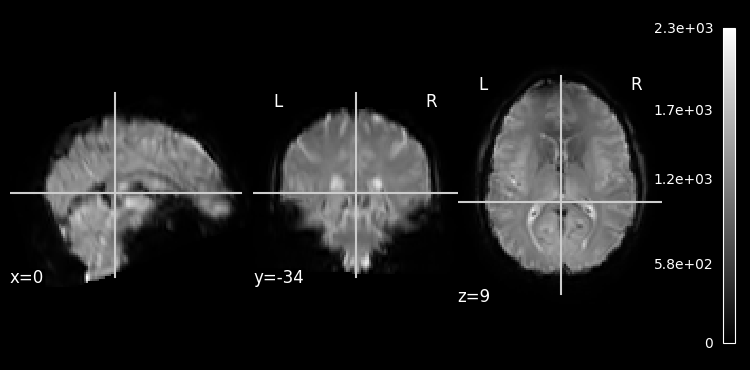

In [ ]:
subject = "01"

base_dir = Path("/content/ds002748")
subject_path = base_dir / f"sub-{subject}" / "func"
nii_files = list(subject_path.glob("*_desc-preproc_bold.nii.gz"))

fmri_file = nii_files[0]
mean_fmri = image.mean_img(fmri_file)

plotting.plot_epi(mean_fmri)
plotting.show()

Before extracting ROI time series, the atlas is resampled to match the spatial resolution and affine transformation of the functional image.

Nearest-neighbor interpolation is used to preserve discrete ROI labels.

The affine matrices are printed to confirm proper alignment.

In [ ]:
atlas_resampled = image.resample_to_img(
    atlas,
    fmri_file,
    interpolation="nearest"
)

print(atlas_resampled.affine, "\n")
print(mean_fmri.affine)

[[   2.     0.     0.   -96.5]
 [   0.     2.     0.  -132.5]
 [   0.     0.     2.   -78.5]
 [   0.     0.     0.     1. ]] 

[[   2.     0.     0.   -96.5]
 [   0.     2.     0.  -132.5]
 [   0.     0.     2.   -78.5]
 [   0.     0.     0.     1. ]]


### Mapping ROI Numbers to Matrix Columns and Saving Metadata

The AAL3 label file contains 170 anatomical labels, whereas the atlas image contains 166 active ROIs. This discrepancy occurs because AAL3 deprecated 4 coarse regions (ROIs 35, 36, 81, 82) and replaced them with finer sub-parcels, leaving them with zero voxels in the actual atlas image.

To ensure correct correspondence between our data matrices and brain region names in downstream analyses, this cell:

- Parses the atlas text file to create a robust dictionary mapping ROI numbers to region names.
- Maps the 166 active ROI numbers (derived directly from the resampled atlas image) to their corresponding column indices (0–165) in the time-series matrix.
- Verifies that the 4 deprecated ROIs are correctly absent from the image.
- Saves all mappings and preprocessing parameters to a JSON file (`extraction_metadata.json`) for reliable and reproducible analysis in Notebook 2.

In [ ]:
output_dir = Path("/content/")

atlas_data = image.load_img(atlas_resampled).get_fdata()
unique_labels = np.unique(atlas_data)
unique_labels = unique_labels[unique_labels != 0]
sorted_labels = sorted(unique_labels.astype(int))

roi_to_column = {roi: idx for idx, roi in enumerate(sorted_labels)}

roi_names = {}
with open(labels_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            roi_num = int(parts[0])
            roi_name = parts[1]
            roi_names[roi_num] = roi_name

for roi in [35, 36, 81, 82]:
    print(f"ROI {roi}: '{roi_names[roi]}' — present in image? {roi in roi_to_column}")

column_names = [roi_names[roi_num] for roi_num in sorted_labels]

print(f"\nNumber of columns: {len(column_names)}")


metadata = {
    "atlas": "AAL3v1",
    "n_timepoints": 100,
    "n_rois_in_image": len(sorted_labels),
    "deprecated_rois": [35, 36, 81, 82],
    "column_to_roi": {str(i): int(roi) for i, roi in enumerate(sorted_labels)},
    "column_to_name": {str(i): column_names[i] for i in range(len(column_names))},
    "roi_to_column": {str(roi): idx for roi, idx in roi_to_column.items()},
}

with open(output_dir / "extraction_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved to extraction_metadata.json")

ROI 35: 'Cingulate_Ant_L' — present in image? False
ROI 36: 'Cingulate_Ant_R' — present in image? False
ROI 81: 'Thalamus_L' — present in image? False
ROI 82: 'Thalamus_R' — present in image? False

Number of columns: 166
Metadata saved to extraction_metadata.json


## Signal Extraction and Denoising

For ROI time-series extraction, we use the `NiftiLabelsMasker` from Nilearn.

This function performs several preprocessing steps in a single pipeline:

- Extracts mean signal from each atlas-defined ROI
- Removes confounding effects using using a General Linear Model (GLM)
- Applies temporal detrending to remove low-frequency drifts
- Standardizes signals (z-score normalization)
- Applies temporal band-pass filtering (0.01–0.1 Hz) to retain resting-state relevant fluctuations

Confound regression is performed simultaneously during signal extraction (`.fit_transform`) using:

- 6 Head Motion Parameters: 3 translations (`trans_x, y, z`) and 3 rotations (`rot_x, y, z`).
- Physiological Noise: Mean signals from the Cerebrospinal Fluid (`csf`) and White Matter (`white_matter`).

In [ ]:
tsv_files = list(subject_path.glob("*_desc-confounds_timeseries.tsv"))
confounds_file = tsv_files[0]
confounds_df = pd.read_csv(confounds_file, sep='\t')

basic_confounds = confounds_df[[
    'trans_x', 'trans_y', 'trans_z',
    'rot_x', 'rot_y', 'rot_z',
    'csf', 'white_matter'
]].fillna(0)

masker = NiftiLabelsMasker(
    labels_img=atlas_resampled,
    standardize='zscore_sample',
    detrend=True,
    t_r=2.5,
    low_pass=0.1,
    high_pass=0.01
)

time_series = masker.fit_transform(fmri_file, confounds=basic_confounds)

print("Matrix dimensions (Timepoints x ROIs):", time_series.shape)

Matrix dimensions (Timepoints x ROIs): (100, 166)


## Visualizing Time Series from Selected ROIs

To ensure correct correspondence between atlas labels and extracted time-series columns, we build a mapping from ROI numbers to matrix indices based on the actual labels present in the atlas volume.

Using this safe mapping, we extract and plot the BOLD signals for four  regions: the bilateral Amygdala (ROIs 45, 46) and bilateral Subgenual ACC (ROIs 151, 152).

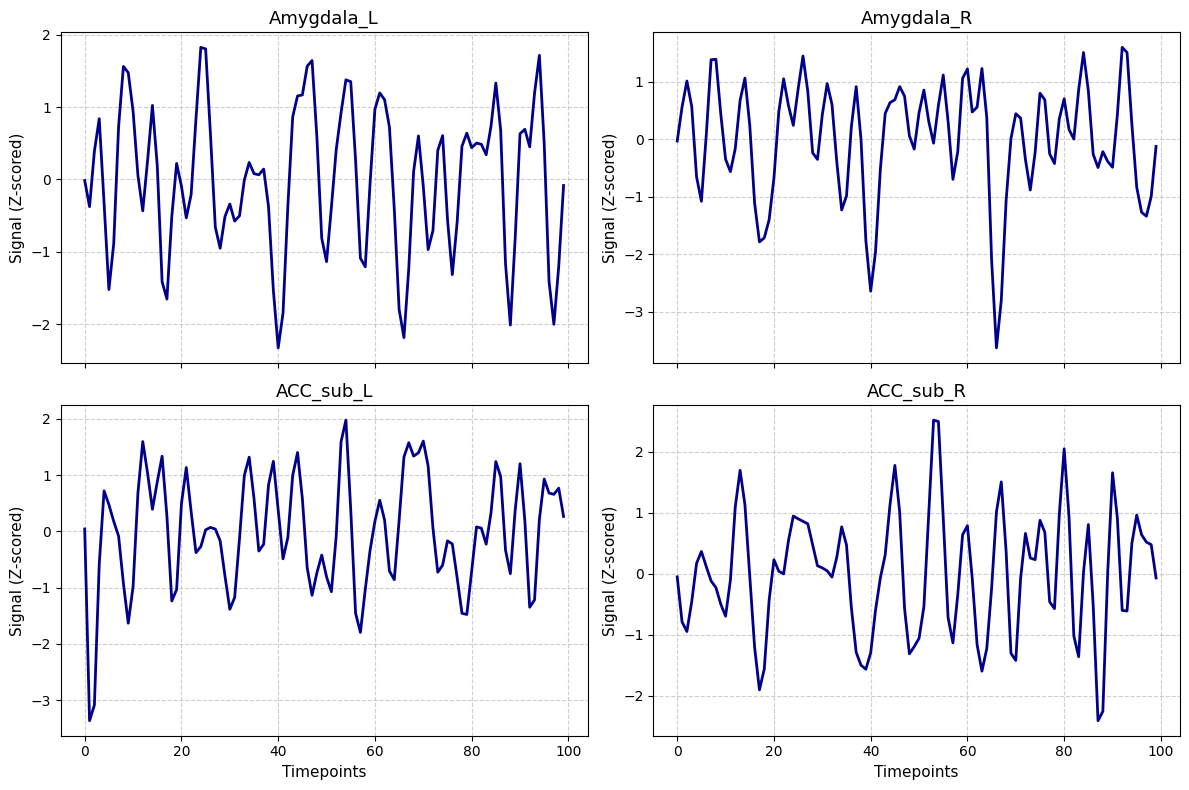

In [ ]:
roi_numbers = [45, 46, 151, 152]

time_axis = range(time_series.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, roi in enumerate(roi_numbers):

    if roi not in roi_to_column:
        print(f"ROI {roi} not found!")
        continue

    col_index     = roi_to_column[roi]
    region_signal = time_series[:, col_index]

    axes[i].plot(time_axis, region_signal,
                 color='darkblue',
                 linewidth=2)

    axes[i].set_title(column_names[col_index], fontsize=13)  # ← fixed
    axes[i].set_ylabel("Signal (Z-scored)", fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.6)

for ax in axes[2:]:
    ax.set_xlabel("Timepoints", fontsize=11)

plt.tight_layout()
plt.show()



---



# Batch Extraction for All Subjects

The same preprocessing parameters used in the single-subject demonstration are applied consistently to every participant. (N=72)

In [ ]:
base_dir = Path("/content/ds002748")
output_dir = Path("/content/timeseries")
output_dir.mkdir(exist_ok=True)

first_subject = sorted(base_dir.glob("sub-*"))[0]
first_func = list((first_subject / "func").glob("*_desc-preproc_bold.nii.gz"))[0]

atlas_resampled = image.resample_to_img(
    atlas,
    first_func,
    interpolation="nearest"
)

print("Atlas resampled to functional space.")

atlas_data = atlas_resampled.get_fdata()
unique_labels = np.unique(atlas_data)
unique_labels = unique_labels[unique_labels != 0]
sorted_labels = sorted(unique_labels.astype(int))

roi_to_column = {roi: idx for idx, roi in enumerate(sorted_labels)}

print(f"Active ROIs in atlas: {len(sorted_labels)}")


for subject_dir in sorted(base_dir.glob("sub-*")):

    subject = subject_dir.name
    func_dir = subject_dir / "func"

    nii_files = list(func_dir.glob("*_desc-preproc_bold.nii.gz"))
    tsv_files = list(func_dir.glob("*_desc-confounds_timeseries.tsv"))

    if len(nii_files) != 1 or len(tsv_files) != 1:
        print(f"{subject} skipped (missing files).")
        continue

    fmri_file = nii_files[0]
    confounds_file = tsv_files[0]

    confounds_df = pd.read_csv(confounds_file, sep='\t')

    basic_confounds = confounds_df[[
        'trans_x', 'trans_y', 'trans_z',
        'rot_x', 'rot_y', 'rot_z',
        'csf', 'white_matter'
    ]].fillna(0)

    masker = NiftiLabelsMasker(
        labels_img=atlas_resampled,
        standardize='zscore_sample',
        detrend=True,
        t_r=2.5,
        low_pass=0.1,
        high_pass=0.01
    )

    time_series = masker.fit_transform(
        fmri_file,
        confounds=basic_confounds
    )

    save_path = output_dir / f"{subject}_timeseries.npy"
    np.save(save_path, time_series)

    print(f"{subject} processed. Shape: {time_series.shape}")

Atlas resampled to functional space.
Active ROIs in atlas: 166
sub-01 processed. Shape: (100, 166)
sub-02 processed. Shape: (100, 166)
sub-03 processed. Shape: (100, 166)
sub-04 processed. Shape: (100, 166)
sub-05 processed. Shape: (100, 166)
sub-06 processed. Shape: (100, 166)
sub-07 processed. Shape: (100, 166)
sub-08 processed. Shape: (100, 166)
sub-09 processed. Shape: (100, 166)
sub-10 processed. Shape: (100, 166)
sub-11 processed. Shape: (100, 166)
sub-12 processed. Shape: (100, 166)
sub-13 processed. Shape: (100, 166)
sub-14 processed. Shape: (100, 166)
sub-15 processed. Shape: (100, 166)
sub-16 processed. Shape: (100, 166)
sub-17 processed. Shape: (100, 166)
sub-18 processed. Shape: (100, 166)
sub-19 processed. Shape: (100, 166)
sub-20 processed. Shape: (100, 166)
sub-21 processed. Shape: (100, 166)
sub-22 processed. Shape: (100, 166)
sub-23 processed. Shape: (100, 166)
sub-24 processed. Shape: (100, 166)
sub-25 processed. Shape: (100, 166)
sub-26 processed. Shape: (100, 166)
s

In [ ]:
import zipfile

output_dir = Path("/content/timeseries")
zip_path = "/content/AAL3_timeseries_all_subjects.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in output_dir.glob("*.npy"):
        zipf.write(file, arcname=file.name)

    zipf.write(
        "/content/extraction_metadata.json",
        arcname="extraction_metadata.json"
    )

print("\nAll time-series extracted and compressed successfully.")
print(f"Zip file saved at: {zip_path}")


All time-series extracted and compressed successfully.
Zip file saved at: /content/AAL3_timeseries_all_subjects.zip
